# Análise Detalhada de Dados de Saúde do Sono: Classificação de Distúrbios do Sono - HealthCheck

### Alunos:
 - GIAN CARLO FAVA
 - FELIPE FERREIRA REZENDE
 - KEVIN DE ALMEIDA BRANDAO
 - SILVIO ALVES DA SILVA JUNIOR

 ## Introdução
 Este notebook tem como objetivo realizar uma análise detalhada do dataset `sleep_health_and_lifestyle_dataset.csv`, aplicando técnicas de Mineração de Dados para a tarefa exclusiva de **Classificação**. A meta é prever a presença de um **distúrbio do sono (`Sleep Disorder`)** em indivíduos, com base em diversas características de saúde e estilo de vida.

 A estrutura e as diretrizes desta análise seguem os requisitos de um problema de classificação, alinhando as etapas de pré-processamento, modelagem, seleção de atributos e avaliação a esse contexto.

As principais etapas que serão abordadas incluem:
1.  Carregamento e Exploração Inicial dos Dados.
2.  Pré-processamento e Exploração dos Dados
3.  Divisão em Conjunto de Treinamento e Teste
4.  Análise de Classificação
5.  Seleção de Atributos
6.  Treinamento e Avaliação com Seleção de Atributos
7.  Comparação de Resultados: Antes e Depois da Seleção de Atributos
8.  Discussão dos Resultados,
9.  Conclusão dos Resultados.
10. Criação e Exportação de Pipeline Completo

## Importação de Bibliotecas Necessárias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
import warnings

# Ignorar warnings para uma saída mais limpa
warnings.filterwarnings('ignore')

# Configurações estéticas para os gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Carregamento e Exploração Inicial dos Dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Carregando o arquivo CSV
try:
    df = pd.read_csv('/content/drive/My Drive/Datasets/sleep_health_and_lifestyle_dataset.csv', sep=',')
    print("Dataset 'sleep_health_and_lifestyle_dataset.csv' carregado com sucesso.")
except FileNotFoundError:
    print("Erro: 'sleep_health_and_lifestyle_dataset.csv' não encontrado.")

print("\n### Primeiras 5 linhas do dataset:")
display(df.head())

print("\n### Informações gerais do dataset:")
df.info()

print("\n### Estatísticas descritivas das colunas numéricas:")
display(df.describe())

print("\n### Distribuição da variável alvo ('Sleep Disorder'):")
# A coluna Sleep Disorder pode ter valores vazios representados como strings vazias.
# Vamos substituir para uma categoria mais explícita, além disso vamos juntar dois tipos de desordem em um só: "Sleep Apnea" e "Insomnia"
# Para isso as strings vazias serão atribuí-das com o número 0 e as com desordem ao número 1
df['Sleep Disorder'] = df['Sleep Disorder'].replace(np.nan, 0)
df['Sleep Disorder'] = df['Sleep Disorder'].replace("Sleep Apnea", 1)
df['Sleep Disorder'] = df['Sleep Disorder'].replace("Insomnia", 1).astype(int)
display(df['Sleep Disorder'].value_counts())
print("\nObserva-se que a maioria dos indivíduos não apresenta um distúrbio do sono, indicando um ligeiro desequilíbrio de classes, mesmo após juntar os dois tipos de desordem.\n\n")

print("\n### Informações gerais do dataset após alteração da coluna Sleep Disorder:")
df.info()

Mounted at /content/drive
Dataset 'sleep_health_and_lifestyle_dataset.csv' carregado com sucesso.

### Primeiras 5 linhas do dataset:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



### Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory us

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000



### Distribuição da variável alvo ('Sleep Disorder'):


,count
Sleep Disorder,
0,219
1,155



Observa-se que a maioria dos indivíduos não apresenta um distúrbio do sono, indicando um ligeiro desequilíbrio de classes, mesmo após juntar os dois tipos de desordem.



### Informações gerais do dataset após alteração da coluna Sleep Disorder:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 


## 2. Pré-processamento e Exploração dos Dados

Esta seção detalha as etapas de preparação dos dados, fundamentais para a qualidade e confiabilidade dos modelos de Classificação.

### 2.1. Tratamento de Valores Ausentes e Colunas Específicas

Vamos identificar e tratar os valores ausentes no dataset e formatar colunas que requerem atenção especial.

In [ ]:
# Removendo 'Person ID' que é apenas um identificador e não uma feature preditiva
df = df.drop(columns=['Person ID'])
print("\nColuna 'Person ID' removida.")

# Tratamento da coluna 'Blood Pressure': Dividir em sistólica e diastólica
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop(columns=['Blood Pressure'])
print("\nColuna 'Blood Pressure' dividida em 'Systolic BP' e 'Diastolic BP' e convertida para numérica.")

# Identificando a quantidade e porcentagem de valores ausentes (após tratamento inicial do Sleep Disorder e Blood Pressure)
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

missing_info = pd.DataFrame({
    'Total Ausentes': missing_data,
    'Porcentagem (%)': missing_percentage.round(2)
})
print("### Valores ausentes por coluna (após tratamento inicial):")
if not missing_info.empty:
    display(missing_info)
else:
    print("Nenhum valor ausente significativo encontrado.")

# Verificando se há valores vazios ou apenas espaços em branco em colunas object (além dos já tratados no Sleep Disorder)
for col in df.select_dtypes(include='object').columns:
    if df[col].apply(lambda x: isinstance(x, str) and x.strip() == '').any():
        print(f"Encontrado valor vazio ou com apenas espaços em branco na coluna categórica: {col}")
        # Preencher com a moda ou 'Unknown' se apropriado
        df[col] = df[col].replace(r'^\s*$', df[col].mode()[0], regex=True) # Replace empty string with mode
        print(f"Valores vazios na coluna '{col}' preenchidos com a moda: {df[col].mode()[0]}")


Coluna 'Person ID' removida.

Coluna 'Blood Pressure' dividida em 'Systolic BP' e 'Diastolic BP' e convertida para numérica.
### Valores ausentes por coluna (após tratamento inicial):
Nenhum valor ausente significativo encontrado.


### 2.2. Tratamento de Dados Inconsistentes ou Redundantes
Buscamos por linhas completamente duplicadas, que podem indicar inconsistências ou redundâncias nos dados. A remoção de duplicatas garante que cada observação seja única e independente.


In [ ]:
# Identificando linhas duplicadas
df_duplicates = df[df.duplicated(keep=False)]

if len(df_duplicates) > 0:
    print('\n### Amostras redundantes ou inconsistentes encontradas:')
    display(df_duplicates)
    original_shape = df.shape[0]
    df = df.drop_duplicates()
    removed_rows = original_shape - df.shape[0]
    print(f"\n{removed_rows} linhas duplicadas foram removidas. Novo shape: {df.shape}")
else:
    print('Não existem valores duplicados exatos no dataset.')


### Amostras redundantes ou inconsistentes encontradas:


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,0,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,0,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,1,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,1,140,90
7,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,0,120,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,1,140,95
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,1,140,95
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,1,140,95
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,1,140,95



248 linhas duplicadas foram removidas. Novo shape: (126, 13)


In [ ]:
print("\n### Nova Distribuição da variável alvo ('Sleep Disorder'):")
display(df['Sleep Disorder'].value_counts())


### Nova Distribuição da variável alvo ('Sleep Disorder'):


,count
Sleep Disorder,
0,73
1,53


### 2.3. Identificação de Variáveis Categóricas e Numéricas
É importante classificar corretamente as variáveis para aplicar as técnicas de pré-processamento apropriadas.

In [ ]:
# Removendo espaços em branco das strings nas colunas categóricas
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Removendo 'Sleep Disorder' da lista de features, pois é a variável alvo
if 'Sleep Disorder' in categorical_cols:
    categorical_cols.remove('Sleep Disorder')
elif 'Sleep Disorder' in numerical_cols:
    numerical_cols.remove('Sleep Disorder')

print(f"\n### Colunas Categóricas ({len(categorical_cols)}):")
print(categorical_cols)
print(f"\n### Colunas Numéricas ({len(numerical_cols)}):")
print(numerical_cols)


### Colunas Categóricas (3):
['Gender', 'Occupation', 'BMI Category']

### Colunas Numéricas (9):
['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']


### 2.4. Codificação de Variáveis Categóricas
As variáveis categóricas precisam ser convertidas em um formato numérico para serem utilizadas pelos algoritmos de Machine Learning. A técnica de One-Hot Encoding é utilizada para isso, criando novas colunas binárias para cada categoria.

In [ ]:
# Aplicando One-Hot Encoding nas features categóricas (excluindo o target)
# 'drop_first=True' é usado para evitar a armadilha da variável dummy (multicolinearidade).
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\n### Shape do dataset após One-Hot Encoding e codificação do target:")
print(df_encoded.shape)
print("\n### Primeiras linhas do dataset após One-Hot Encoding:")
display(df_encoded.head())


### Shape do dataset após One-Hot Encoding e codificação do target:
(126, 24)

### Primeiras linhas do dataset após One-Hot Encoding:


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP,...,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
0,27,6.1,6,42,6,77,4200,0,126,83,...,False,False,False,False,False,True,False,False,False,True
1,28,6.2,6,60,8,75,10000,0,125,80,...,False,False,False,False,False,False,False,False,False,False
3,28,5.9,4,30,8,85,3000,1,140,90,...,False,False,True,False,False,False,False,False,True,False
5,28,5.9,4,30,8,85,3000,1,140,90,...,False,False,False,False,False,True,False,False,True,False
6,29,6.3,6,40,7,82,3500,1,140,90,...,False,False,False,False,False,False,True,False,True,False


### 2.5. Normalização/Escalonamento dos Atributos Numéricos
Normalizar os dados é uma etapa crucial para muitos algoritmos de Machine Learning, especialmente aqueles baseados em distância (como KNN e SVM) ou que assumem uma distribuição normal dos dados. O `StandardScaler` transforma os dados para que tenham média 0 e desvio padrão 1.


In [ ]:
# Aplicando StandardScaler às colunas numéricas
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("\n### Estatísticas descritivas das colunas numéricas após escalonamento:")
display(df_encoded[numerical_cols].describe().round(4))


### Estatísticas descritivas das colunas numéricas após escalonamento:


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP
count,126.0000,126.0000,126.0000,126.0000,126.0000,126.0000,126.0000,126.0000,126.0000
mean,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000
std,1.0040,1.0040,1.0040,1.0040,1.0040,1.0040,1.0040,1.0040,1.0040
min,-1.6169,-1.6797,-2.5957,-1.4136,-1.4232,-1.2462,-2.1130,-1.6709,-1.5466
25%,-0.7945,-0.9064,-0.9806,-0.6700,-0.8484,-0.6264,-0.9587,-1.0379,-0.7258
50%,-0.0288,0.1248,-0.1730,0.0736,-0.2737,-0.2132,0.1956,0.2281,0.0951
75%,0.8787,0.8660,0.6345,0.8172,0.8758,0.2000,0.7727,0.8610,0.8339
max,2.0130,1.8005,1.4420,1.5607,1.4506,3.0925,1.9270,1.7472,1.7369


### 2.6. Análise de Distribuição e Outliers para Atributos Numéricos
Visualizar a distribuição dos atributos numéricos ajuda a entender sua variabilidade e identificar possíveis outliers. Para classificação, outliers podem influenciar a fronteira de decisão dos modelos.



### Boxplots dos Atributos Numéricos (Escalonados):


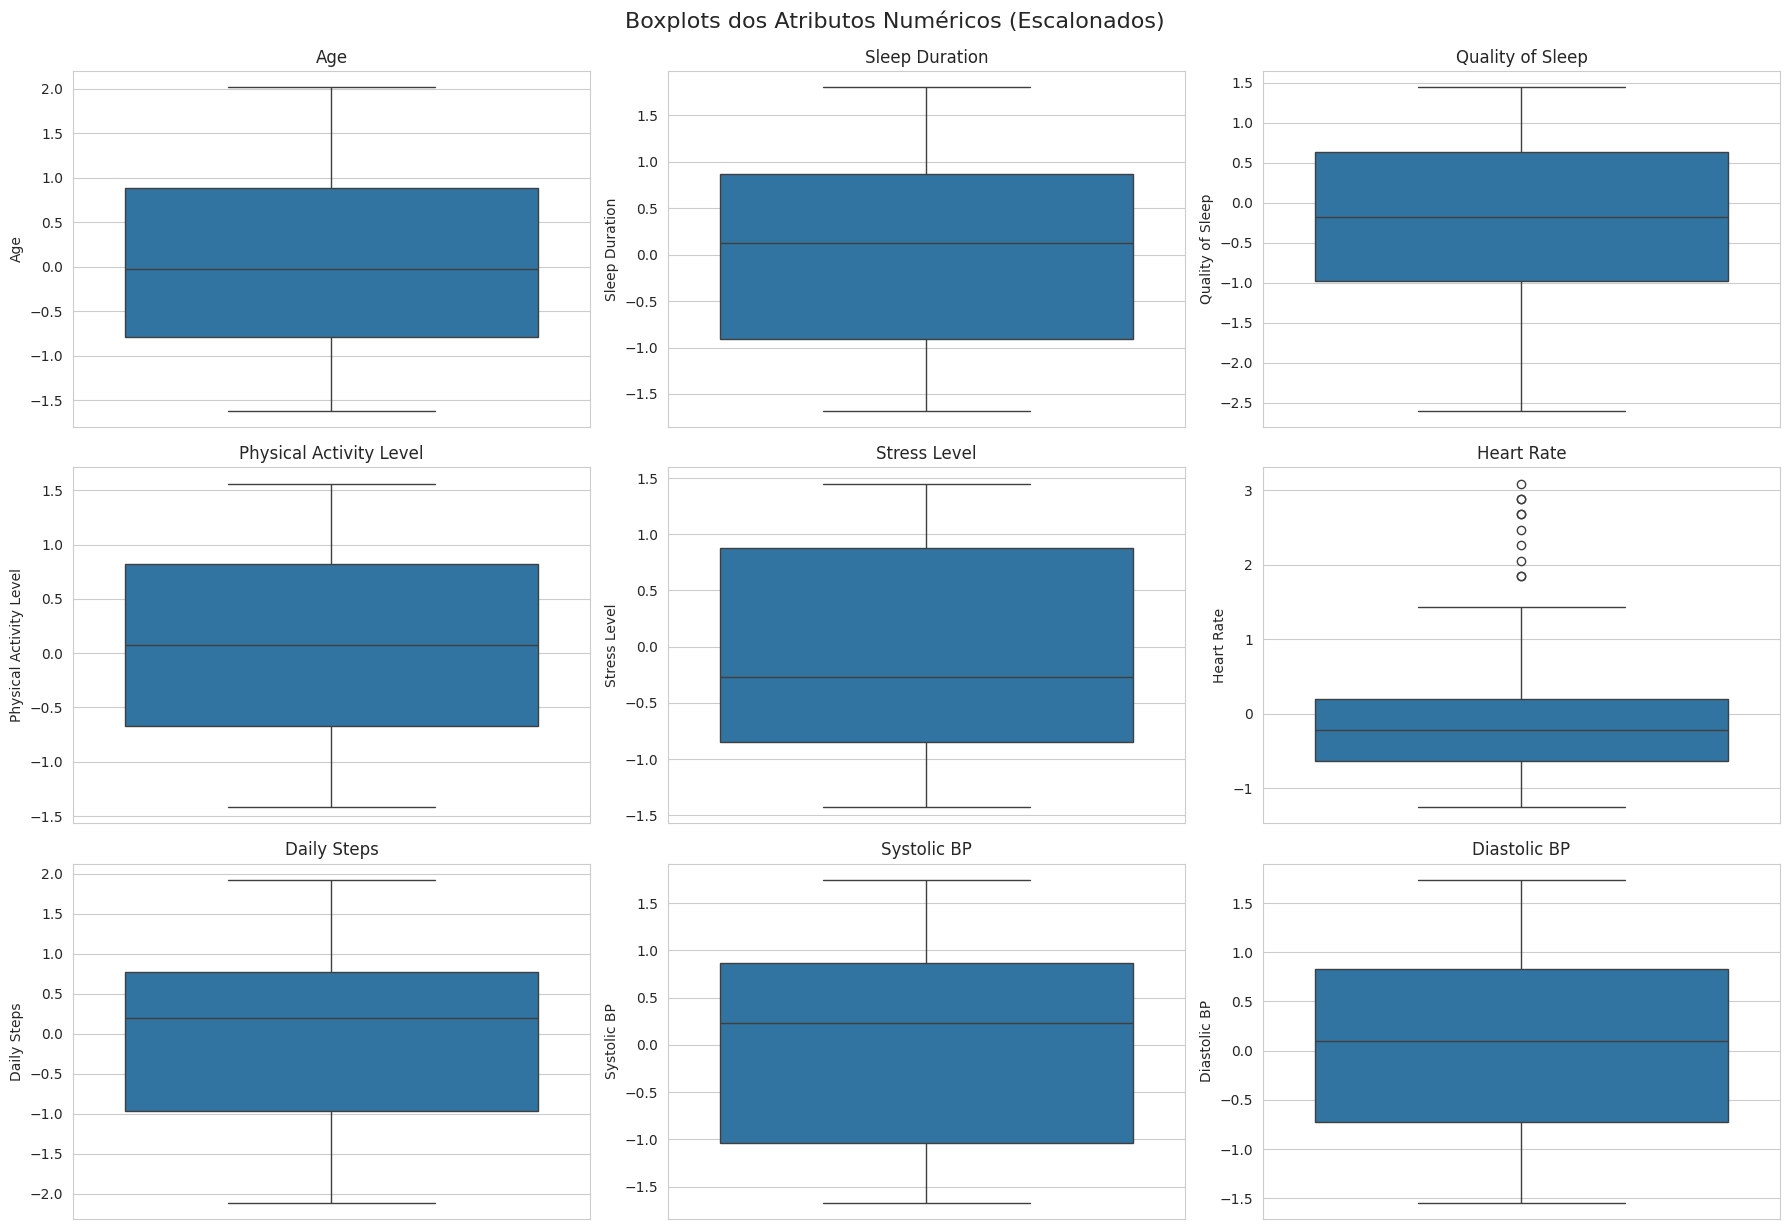


### Histogramas dos Atributos Numéricos (Escalonados):


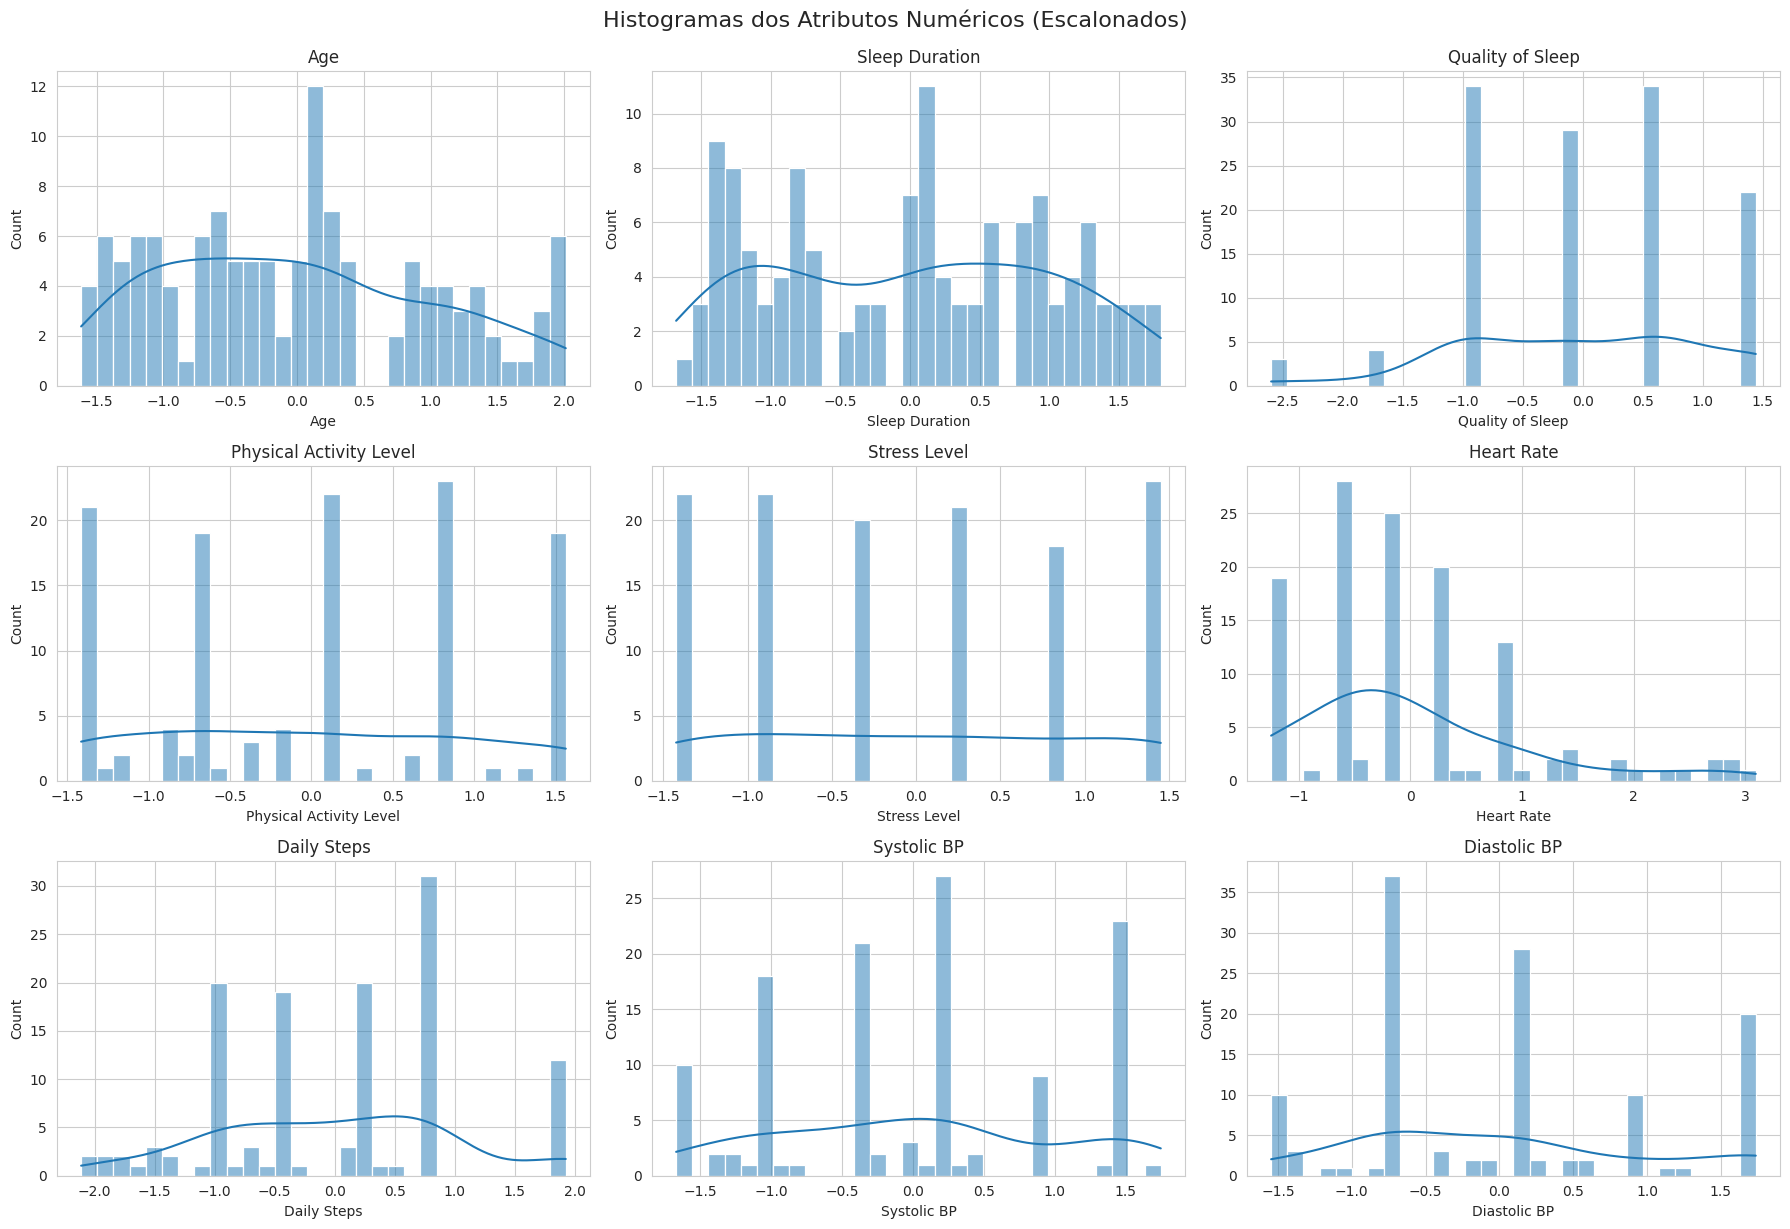

In [ ]:
# Boxplots para as colunas numéricas
print("\n### Boxplots dos Atributos Numéricos (Escalonados):")
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Ajustado para mais colunas numéricas
    sns.boxplot(y=df_encoded[col])
    plt.title(col)
plt.tight_layout()
plt.suptitle('Boxplots dos Atributos Numéricos (Escalonados)', y=1.02, fontsize=16)
plt.show()

# Histogramas para as colunas numéricas
print("\n### Histogramas dos Atributos Numéricos (Escalonados):")
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Ajustado para mais colunas numéricas
    sns.histplot(df_encoded[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.suptitle('Histogramas dos Atributos Numéricos (Escalonados)', y=1.02, fontsize=16)
plt.show()

### 2.7. Análise de Correlação
A análise de correlação nos ajuda a entender a relação linear entre os atributos e a variável alvo (`Sleep Disorder`), bem como a identificar potenciais multicolinearidades entre as features. Isso é crucial para a interpretabilidade e para o desempenho de alguns modelos de classificação.


### Correlações com a Variável Alvo 'Sleep Disorder':


,Sleep Disorder
Systolic BP,0.570856
Diastolic BP,0.553503
BMI Category_Overweight,0.441542
Heart Rate,0.359779
BMI Category_Obese,0.284642
Occupation_Nurse,0.240884
Age,0.239889
Occupation_Teacher,0.210309
Stress Level,0.201083
Occupation_Salesperson,0.173721


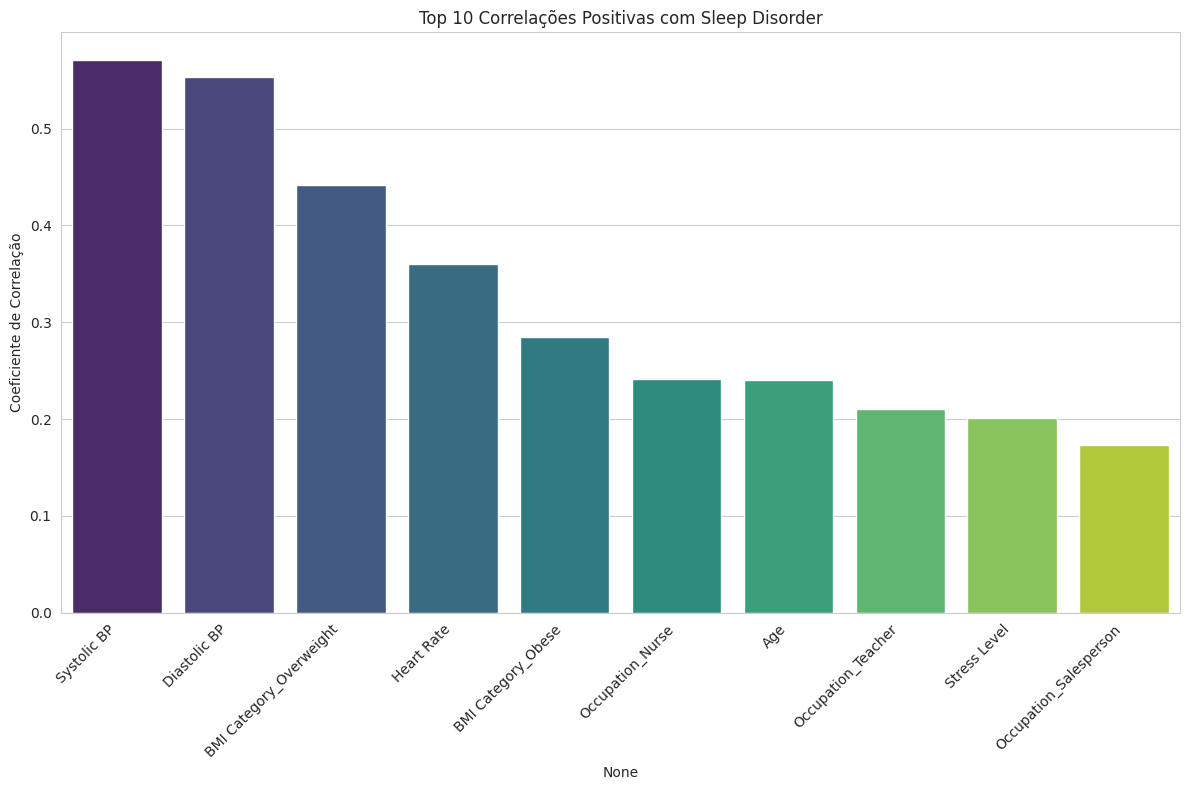

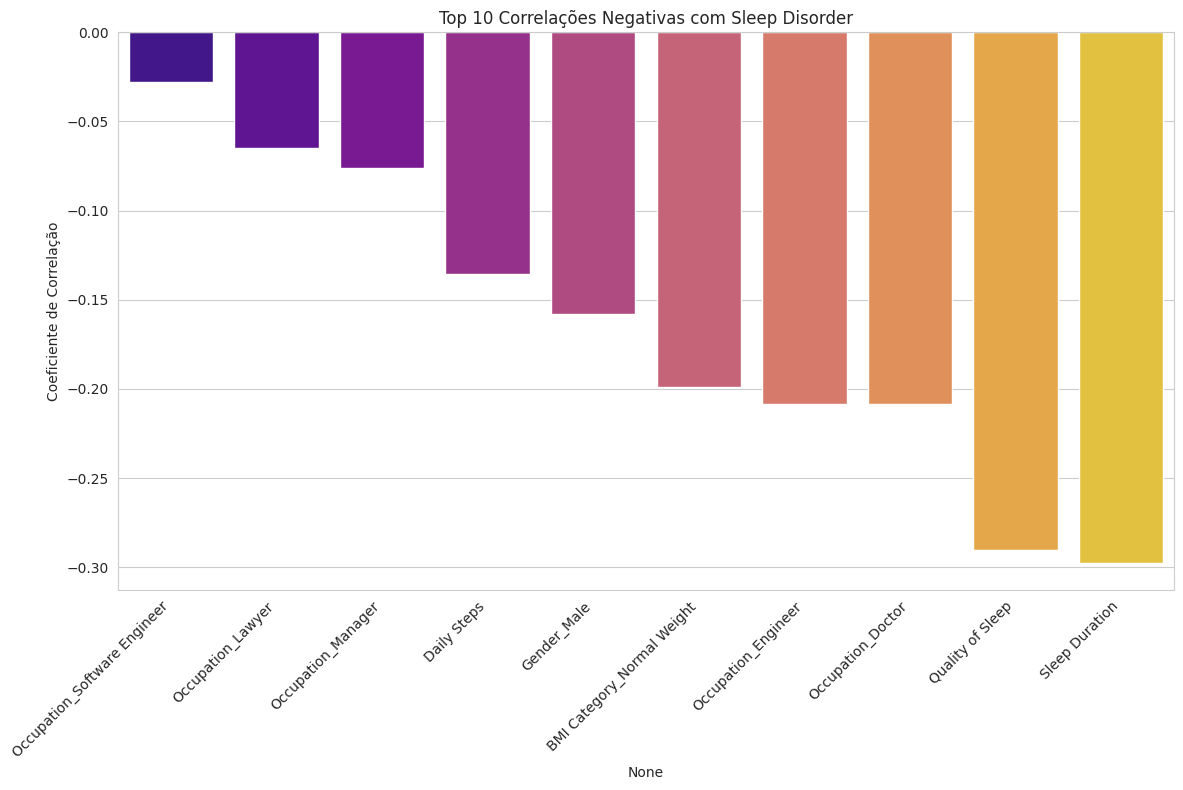


### Análise de Correlação entre as Features Numéricas Originais e a Variável Alvo:


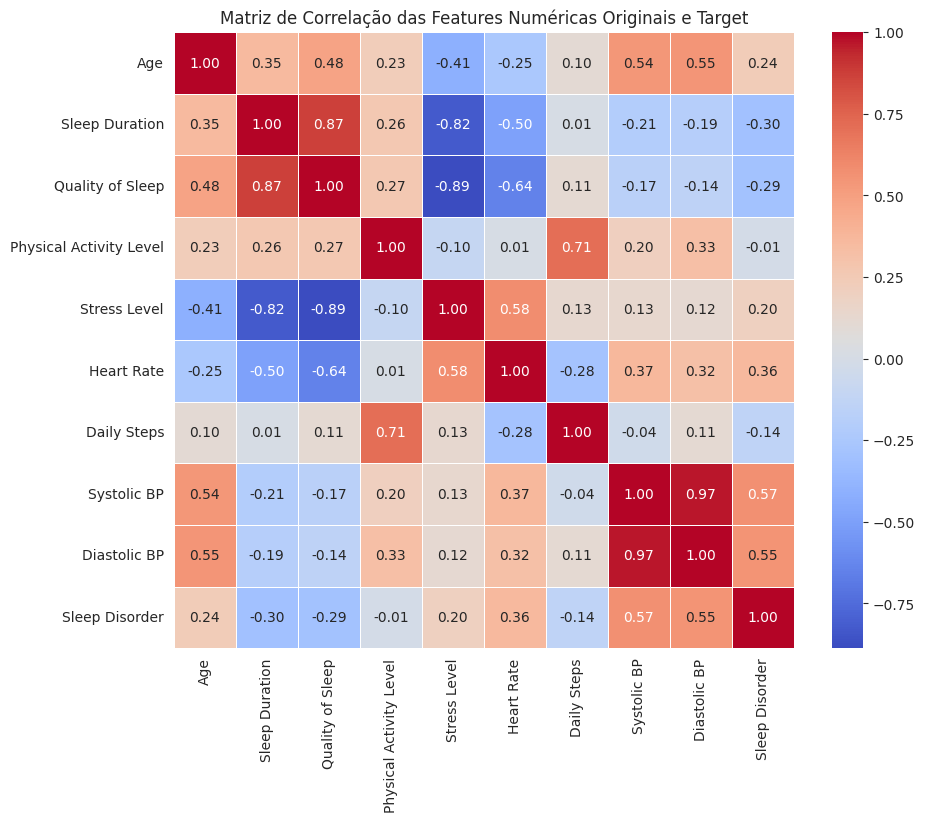

In [ ]:
# Criando um DataFrame para a análise de correlação incluindo todas as features processadas e o target
correlation_df = df_encoded.copy()

# Calculando a matriz de correlação
corr_matrix = correlation_df.corr()

# Visualizando as correlações com a variável alvo 'Sleep Disorder'
print("\n### Correlações com a Variável Alvo 'Sleep Disorder':")
# Ordena as features pela correlação com 'Sleep Disorder' (descrescente)
target_corr = corr_matrix['Sleep Disorder'].sort_values(ascending=False)
# Excluindo a correlação de 1.0 da variável alvo consigo mesma
target_corr = target_corr.drop('Sleep Disorder')
# Exibe todas as correlações com a variável alvo, ordenadas e formatadas
display(target_corr.round(6))

# Plotando as top 10 correlações positivas com 'Sleep Disorder'
plt.figure(figsize=(12, 8))
sns.barplot(x=target_corr.head(10).index, y=target_corr.head(10).values, palette='viridis')
plt.title('Top 10 Correlações Positivas com Sleep Disorder')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coeficiente de Correlação')
plt.tight_layout()
plt.show()

# Plotando as top 10 correlações negativas com 'Sleep Disorder'
plt.figure(figsize=(12, 8))
sns.barplot(x=target_corr.tail(10).index, y=target_corr.tail(10).values, palette='plasma')
plt.title('Top 10 Correlações Negativas com Sleep Disorder')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coeficiente de Correlação')
plt.tight_layout()
plt.show()

print("\n### Análise de Correlação entre as Features Numéricas Originais e a Variável Alvo:")
# Seleciona apenas as features numéricas originais e o target para um heatmap mais legível
numerical_features_with_target_corr_df = df_encoded[numerical_cols + ['Sleep Disorder']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_features_with_target_corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Features Numéricas Originais e Target')
plt.show()


### Observações Principais da Análise de Correlação:
Com base nos coeficientes de correlação (Lembre-se que 'Sleep Disorder' está codificado numericamente, então a interpretação de positivo/negativo dependerá da ordem de codificação das classes):
- **Correlações Positivas Mais Fortes com 'Sleep Disorder':**
  - `Systolic BP` (0.57): A pressão sistólica mostra a correlação positiva mais forte com distúrbios do sono.
  - `Diastolic BP` (0.55): A pressão diastólica também apresenta uma correlação positiva forte.
  - `BMI Category_Overweight` (0.44): Indivíduos com sobrepeso têm uma correlação positiva moderada com distúrbios do sono.
  - `Heart Rate` (0.36): A frequência cardíaca mostra uma correlação positiva moderada.
  - `BMI Category_Obese` (0.28): Indivíduos obesos mostram uma correlação positiva moderada.
  - `Occupation_Nurse` (0.24) e `Age` (0.24): Ser enfermeiro e a idade mostram correlações positivas moderadas.
- **Correlações Negativas Mais Fortes com 'Sleep Disorder':**
  - `Quality of Sleep` (-0.29) e `Sleep Duration` (-0.30): A qualidade e duração do sono são as variáveis mais fortemente correlacionadas negativamente com distúrbios do sono, o que é esperado.
  - `Daily Steps` (-0.14): Um maior número de passos diários tem uma correlação negativa moderada.
  - `Gender_Male` (-0.16): Ser do sexo masculino tem uma correlação negativa moderada com distúrbios do sono.
  - `BMI Category_Normal Weight` (-0.20): Indivíduos com peso normal mostram uma correlação negativa moderada.
  - `Occupation_Engineer` (-0.21) e `Occupation_Doctor` (-0.21): Algumas ocupações mostram correlações negativas moderadas com distúrbios do sono.
- **Observações Gerais:**
  - Pressão arterial (sistólica e diastólica) e categorias de IMC (sobrepeso e obesidade) são os indicadores de saúde mais fortemente associados positivamente a distúrbios do sono.
  - A qualidade e duração do sono são, como esperado, fortemente correlacionadas negativamente com a presença de distúrbios.
  - Fatores ocupacionais e idade também desempenham um papel, com algumas ocupações e o aumento da idade mostrando correlação positiva com distúrbios do sono, enquanto outras ocupações mostram correlação negativa.
  - A correlação negativa de `Physical Activity Level` e `Daily Steps` com `Sleep Disorder` sugere que indivíduos com distúrbios do sono (codificados com valores numéricos mais altos) tendem a ter menor atividade física e menos passos diários.
  - É importante lembrar que correlação não implica causalidade. Essas observações sugerem associações que podem ser exploradas em análises mais aprofundadas ou modelagem preditiva.


## 3. Divisão em Conjunto de Treinamento e Teste
Para garantir uma avaliação imparcial dos modelos e evitar overfitting, dividimos o dataset em conjuntos de treinamento e teste. O conjunto de treinamento é usado para ajustar os parâmetros do modelo, enquanto o conjunto de teste é usado para avaliar seu desempenho em dados não vistos. Para problemas de classificação, a estratificação da variável alvo é crucial para manter a proporção das classes em ambos os conjuntos.


In [ ]:
# Definindo X (features) e y (target)
X = df_encoded.drop(columns=['Sleep Disorder'])
y = df_encoded['Sleep Disorder'] # Target para classificação

# Divisão para Classificação
# `stratify=y` garante que a proporção das classes seja mantida nos conjuntos de treinamento e teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")
print(f"\n### Divisão para Classificação:")
print(f"  Shape de X_train: {X_train.shape}")
print(f"  Shape de X_test: {X_test.shape}")
print(f"  Shape de y_train: {y_train.shape}")
print(f"  Shape de y_test: {y_test.shape}")

print("\n### Proporção das classes no conjunto de treinamento:")
display(pd.Series(y_train).value_counts(normalize=True).sort_index())
print("\n### Proporção das classes no conjunto de teste:")
display(pd.Series(y_test).value_counts(normalize=True).sort_index())
print("As proporções foram mantidas devido à estratificação.")

Shape de X (features): (126, 23)
Shape de y (target): (126,)

### Divisão para Classificação:
  Shape de X_train: (100, 23)
  Shape de X_test: (26, 23)
  Shape de y_train: (100,)
  Shape de y_test: (26,)

### Proporção das classes no conjunto de treinamento:


,proportion
Sleep Disorder,
0,0.58
1,0.42



### Proporção das classes no conjunto de teste:


,proportion
Sleep Disorder,
0,0.576923
1,0.423077


As proporções foram mantidas devido à estratificação.


## 4. Análise de Classificação
Nesta seção, abordaremos a tarefa de classificar a presença de distúrbios do sono (`Sleep Disorder`) utilizando diferentes modelos de classificação.

### 4.1. Treinamento e Avaliação do Modelo Inicial (Classificação)
Avaliaremos o desempenho de diversos modelos de classificação no conjunto de teste, utilizando Acurácia, F1-Score, Matriz de Confusão e Relatório de Classificação como métricas.

In [ ]:
# Modelos de Classificação a serem utilizados
models_clf = []
models_clf.append(('LR - Regressão Logística', LogisticRegression(solver='liblinear', random_state=42, multi_class='ovr')))
models_clf.append(('LDA - Linear Discriminant Analysis', LinearDiscriminantAnalysis()))
models_clf.append(('KNN - K-Neighbors Classifier', KNeighborsClassifier()))
models_clf.append(('CART - Decision Tree Classifier', DecisionTreeClassifier(random_state=42)))
models_clf.append(('NB - Gaussian Naive Bayes', GaussianNB()))
models_clf.append(('SVM - Support Vector Machine', SVC(gamma='auto', random_state=42)))
models_clf.append(('RFC - Random Forest Classifier', RandomForestClassifier(random_state=42, n_estimators=100)))
models_clf.append(('GBC - Gradient Boosting Classifier', GradientBoostingClassifier(random_state=42, n_estimators=100)))

scoring = 'accuracy'
names_clf = []

for name, model in models_clf:
    names_clf.append(name)

In [ ]:
print("\n### Avaliação dos Modelos de Classificação Iniciais (no Conjunto de Teste):")
results_clf_test = {}
for name, model in models_clf:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(f"\n--- {name} ---")
    accuracy = accuracy_score(y_test, predictions)
    # F1-Score para multiclass com average='weighted' para lidar com desbalanceamento
    f1 = f1_score(y_test, predictions, average='weighted')
    results_clf_test[name] = {'Acurácia': accuracy, 'F1-Score': f1}
    print(f"Acurácia: {accuracy:.4f}")
    print(f"F1-Score (Weighted): {f1:.4f}")
    print("Matriz de Confusão:")
    # Use unique values from the 'Sleep Disorder' column for class names
    class_names = [str(c) for c in sorted(df['Sleep Disorder'].unique())]
    display(pd.DataFrame(confusion_matrix(y_test, predictions),
                         index=[f'Real {c}' for c in class_names],
                         columns=[f'Pred {c}' for c in class_names]))
    print("Relatório de Classificação:")
    print(classification_report(y_test, predictions, target_names=class_names))


### Avaliação dos Modelos de Classificação Iniciais (no Conjunto de Teste):

--- LR - Regressão Logística ---
Acurácia: 0.7692
F1-Score (Weighted): 0.7692
Matriz de Confusão:


,Pred 0,Pred 1
Real 0,12,3
Real 1,3,8


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        15
           1       0.73      0.73      0.73        11

    accuracy                           0.77        26
   macro avg       0.76      0.76      0.76        26
weighted avg       0.77      0.77      0.77        26


--- LDA - Linear Discriminant Analysis ---
Acurácia: 0.7308
F1-Score (Weighted): 0.7320
Matriz de Confusão:


,Pred 0,Pred 1
Real 0,11,4
Real 1,3,8


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        15
           1       0.67      0.73      0.70        11

    accuracy                           0.73        26
   macro avg       0.73      0.73      0.73        26
weighted avg       0.74      0.73      0.73        26


--- KNN - K-Neighbors Classifier ---
Acurácia: 0.7692
F1-Score (Weighted): 0.7692
Matriz de Confusão:


...

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        15
           1       0.73      0.73      0.73        11

    accuracy                           0.77        26
   macro avg       0.76      0.76      0.76        26
weighted avg       0.77      0.77      0.77        26


--- RFC - Random Forest Classifier ---
Acurácia: 0.7692
F1-Score (Weighted): 0.7649
Matriz de Confusão:


,Pred 0,Pred 1
Real 0,13,2
Real 1,4,7


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        15
           1       0.78      0.64      0.70        11

    accuracy                           0.77        26
   macro avg       0.77      0.75      0.76        26
weighted avg       0.77      0.77      0.76        26


--- GBC - Gradient Boosting Classifier ---
Acurácia: 0.8462
F1-Score (Weighted): 0.8433
Matriz de Confusão:


,Pred 0,Pred 1
Real 0,14,1
Real 1,3,8


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.93      0.88        15
           1       0.89      0.73      0.80        11

    accuracy                           0.85        26
   macro avg       0.86      0.83      0.84        26
weighted avg       0.85      0.85      0.84        26



## 5. Seleção de Atributos
A seleção de atributos é uma etapa crucial em mineração de dados para melhorar a performance do modelo, reduzir o overfitting, diminuir a complexidade computacional e aumentar a interpretabilidade. Vamos utilizar o método `SelectKBest` com a função de pontuação `f_classif` para identificar os atributos mais relevantes para a tarefa de classificação.

### 5.1. Seleção de Atributos para Classificação (baseada em F-score)
Utilizaremos `SelectKBest` com a função de pontuação `f_classif` (ANOVA F-value) para selecionar um número adequado de atributos mais discriminativos para a variável alvo categórica (`Sleep Disorder`). Dado o tamanho do dataset e número de features, selecionaremos 10 atributos.


In [ ]:
selector_clf = SelectKBest(score_func=f_classif, k=15) # Reduzido para 15 features, dado o tamanho do dataset.
X_train_selected_clf = selector_clf.fit_transform(X_train, y_train)
X_test_selected_clf = selector_clf.transform(X_test)

# Obtendo os nomes dos atributos selecionados
selected_features_clf = X.columns[selector_clf.get_support()]
print(f"### Top 15 atributos selecionados para Classificação:\n{selected_features_clf.tolist()}")


### Top 15 atributos selecionados para Classificação:
['Age', 'Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Heart Rate', 'Systolic BP', 'Diastolic BP', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Nurse', 'Occupation_Salesperson', 'Occupation_Teacher', 'BMI Category_Normal Weight', 'BMI Category_Obese', 'BMI Category_Overweight']


## 6. Treinamento e Avaliação com Seleção de Atributos
Após a seleção de atributos, vamos reavaliar os modelos de Classificação para observar o impacto da redução de dimensionalidade no desempenho.


### 6.1. Análise de Classificação com Atributos Selecionados
Re-treinamento e avaliação dos modelos de classificação utilizando apenas os atributos selecionados.


In [ ]:
print("\n### Avaliação dos Modelos de Classificação (com atributos selecionados) no Conjunto de Teste:")
results_clf_selected_test = {}
for name, model in models_clf:
    model.fit(X_train_selected_clf, y_train)
    predictions_selected = model.predict(X_test_selected_clf)
    print(f"\n--- {name} (com atributos selecionados) ---")
    accuracy = accuracy_score(y_test, predictions_selected)
    f1 = f1_score(y_test, predictions_selected, average='weighted')
    results_clf_selected_test[name] = {'Acurácia': accuracy, 'F1-Score': f1}
    print(f"Acurácia: {accuracy:.4f}")
    print(f"F1-Score (Weighted): {f1:.4f}")
    print("Matriz de Confusão:")
    # Use unique values from the 'Sleep Disorder' column for class names
    class_names = [str(c) for c in sorted(df['Sleep Disorder'].unique())]
    display(pd.DataFrame(confusion_matrix(y_test, predictions_selected),
                         index=[f'Real {c}' for c in class_names],
                         columns=[f'Pred {c}' for c in class_names]))
    print("Relatório de Classificação:")
    print(classification_report(y_test, predictions_selected, target_names=class_names))


### Avaliação dos Modelos de Classificação (com atributos selecionados) no Conjunto de Teste:

--- LR - Regressão Logística (com atributos selecionados) ---
Acurácia: 0.7692
F1-Score (Weighted): 0.7692
Matriz de Confusão:


,Pred 0,Pred 1
Real 0,12,3
Real 1,3,8


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        15
           1       0.73      0.73      0.73        11

    accuracy                           0.77        26
   macro avg       0.76      0.76      0.76        26
weighted avg       0.77      0.77      0.77        26


--- LDA - Linear Discriminant Analysis (com atributos selecionados) ---
Acurácia: 0.7308
F1-Score (Weighted): 0.7287
Matriz de Confusão:


,Pred 0,Pred 1
Real 0,12,3
Real 1,4,7


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        15
           1       0.70      0.64      0.67        11

    accuracy                           0.73        26
   macro avg       0.72      0.72      0.72        26
weighted avg       0.73      0.73      0.73        26


--- KNN - K-Neighbors Classifier (com atributos selecionados) ---
Acurácia: 0.8077
F1-Score (Weighted): 0.8062
Matriz de Confusão:


...

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        15
           1       0.80      0.73      0.76        11

    accuracy                           0.81        26
   macro avg       0.81      0.80      0.80        26
weighted avg       0.81      0.81      0.81        26


--- RFC - Random Forest Classifier (com atributos selecionados) ---
Acurácia: 0.7692
F1-Score (Weighted): 0.7649
Matriz de Confusão:


,Pred 0,Pred 1
Real 0,13,2
Real 1,4,7


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        15
           1       0.78      0.64      0.70        11

    accuracy                           0.77        26
   macro avg       0.77      0.75      0.76        26
weighted avg       0.77      0.77      0.76        26


--- GBC - Gradient Boosting Classifier (com atributos selecionados) ---
Acurácia: 0.8462
F1-Score (Weighted): 0.8433
Matriz de Confusão:


,Pred 0,Pred 1
Real 0,14,1
Real 1,3,8


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.93      0.88        15
           1       0.89      0.73      0.80        11

    accuracy                           0.85        26
   macro avg       0.86      0.83      0.84        26
weighted avg       0.85      0.85      0.84        26



## 7. Comparação de Resultados: Antes e Depois da Seleção de Atributos

In [ ]:
# Criando DataFrames para comparação visual da acurácia no conjunto de teste
print("\n### Comparação de Acurácia no Conjunto de Teste:")
comparison_test = pd.DataFrame({
    'Modelo': names_clf,
    'Acurácia Inicial (Teste)': [results_clf_test[name]['Acurácia'] for name in names_clf],
    'Acurácia com Seleção (Teste)': [results_clf_selected_test[name]['Acurácia'] for name in names_clf]
})
comparison_test['Diferença'] = (comparison_test['Acurácia com Seleção (Teste)'] - comparison_test['Acurácia Inicial (Teste)']).round(4)
display(comparison_test)


### Comparação de Acurácia no Conjunto de Teste:


,Modelo,Acurácia Inicial (Teste),Acurácia com Seleção (Teste),Diferença
0,LR - Regressão Logística,0.769231,0.769231,0.0000
1,LDA - Linear Discriminant Analysis,0.730769,0.730769,0.0000
2,KNN - K-Neighbors Classifier,0.769231,0.807692,0.0385
3,CART - Decision Tree Classifier,0.692308,0.692308,0.0000
4,NB - Gaussian Naive Bayes,0.538462,0.692308,0.1538
5,SVM - Support Vector Machine,0.769231,0.807692,0.0385
6,RFC - Random Forest Classifier,0.769231,0.769231,0.0000
7,GBC - Gradient Boosting Classifier,0.846154,0.846154,0.0000


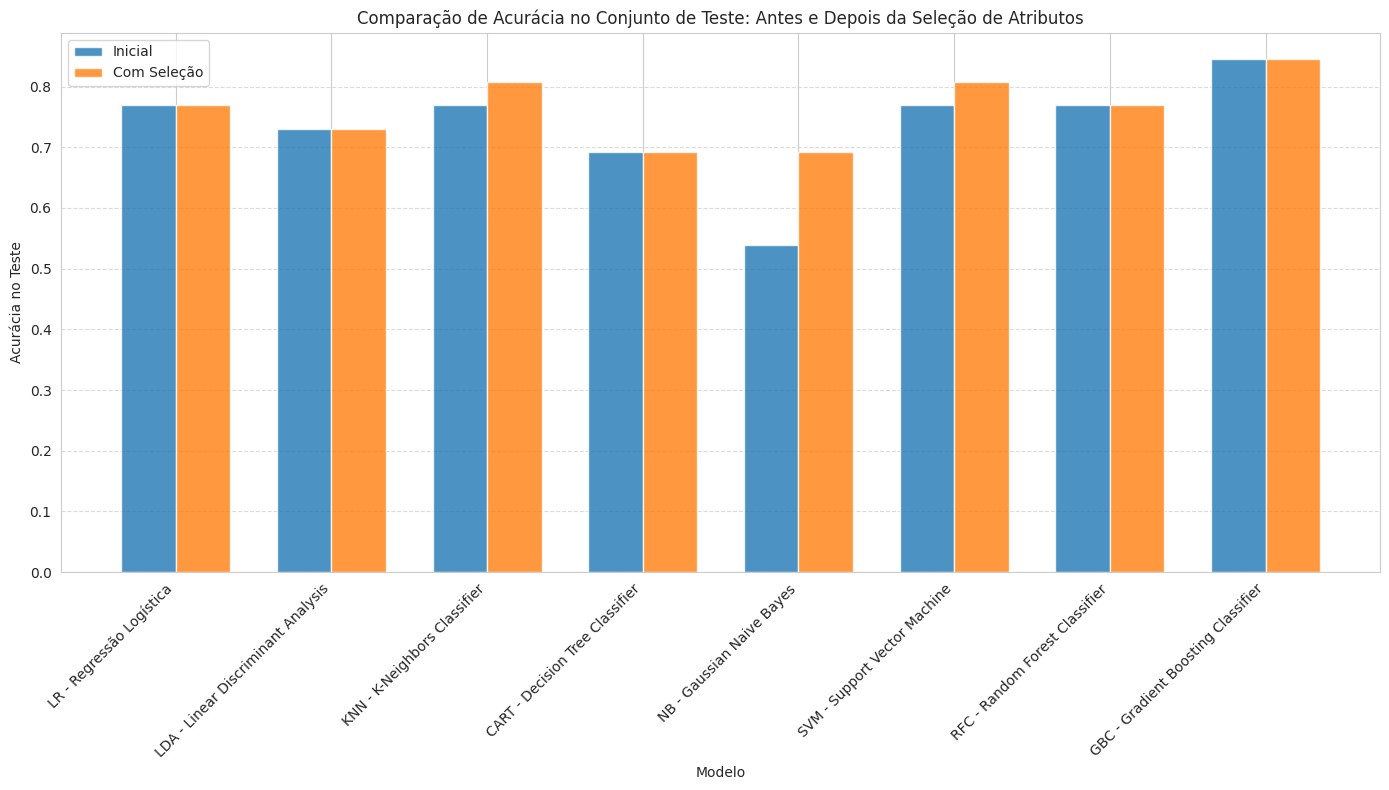

In [ ]:
# Visualizando a comparação da acurácia no conjunto de teste
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(comparison_test))
width = 0.35
bars1 = ax.bar(x - width/2, comparison_test['Acurácia Inicial (Teste)'], width, label='Inicial', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_test['Acurácia com Seleção (Teste)'], width, label='Com Seleção', alpha=0.8)
ax.set_xlabel('Modelo')
ax.set_ylabel('Acurácia no Teste')
ax.set_title('Comparação de Acurácia no Conjunto de Teste: Antes e Depois da Seleção de Atributos')
ax.set_xticks(x)
ax.set_xticklabels(comparison_test['Modelo'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 8. Discussão dos Resultados (alterar)

### 8.1. Pré-processamento
O pré-processamento do dataset `sleep_health_and_lifestyle_dataset.csv` foi crucial para lidar com suas características específicas, preparando-o para a tarefa de classificação de distúrbios do sono.

*   **Tratamento de Colunas:** A coluna `Person ID` foi removida, pois é um identificador e não uma feature preditiva, não agregando valor ao modelo preditivo. A coluna `Blood Pressure` foi desagregada em `Systolic BP` e `Diastolic BP`, convertidas para tipo numérico (`int`), permitindo que essas importantes métricas de saúde fossem utilizadas pelos algoritmos de Machine Learning.

*   **Tratamento de Valores Ausentes e Inconsistências na Variável Alvo:** A variável alvo `Sleep Disorder` inicialmente continha valores ausentes (representados como `NaN`). Estes foram explicitamente substituídos por `0` (representando 'No Disorder'). Além disso, as categorias 'Sleep Apnea' e 'Insomnia' foram unificadas e codificadas como `1` (representando a presença de um distúrbio do sono). Essa abordagem simplifica o problema para uma classificação binária (com ou sem distúrbio) e garante que todos os registros tenham um valor definido para a variável alvo.

*   **Verificação de Outros Valores Ausentes:** Após o tratamento inicial da variável alvo e da coluna 'Blood Pressure', foi realizada uma verificação em todo o dataset. Nenhuma outra coluna apresentou valores ausentes, o que indica um dataset relativamente limpo neste aspecto. Também verificamos e tratamos possíveis strings vazias ou com apenas espaços em branco nas colunas categóricas, garantindo a consistência dos dados.

*   **Tratamento de Duplicatas:** A identificação e remoção de `248` linhas completamente duplicadas foi um passo fundamental. A presença de tantas duplicatas poderia enviesar o treinamento dos modelos, levando a uma superestimação do desempenho. A remoção resultou em um dataset reduzido para `126` observações, garantindo que cada entrada represente uma observação única e independente.

*   **Distribuição da Variável Alvo Após Tratamento de Duplicatas:** A nova distribuição da variável alvo após a remoção das duplicatas mostrou um desequilíbrio reduzido, mas ainda presente, com `73` instâncias da classe `0` (sem distúrbio) e `53` instâncias da classe `1` (com distúrbio). Este desequilíbrio será levado em consideração na avaliação dos modelos, utilizando métricas apropriadas como F1-Score.

*   **Identificação e Codificação de Variáveis Categóricas:** As variáveis categóricas (`Gender`, `Occupation`, `BMI Category`) foram corretamente identificadas. Espaços em branco nas strings foram removidos para garantir a uniformidade. Em seguida, a técnica de One-Hot Encoding foi aplicada (com `drop_first=True` para evitar a multicolinearidade), convertendo-as em um formato numérico binário. Isso expandiu a dimensionalidade do dataset para 23 features, tornando-o compatível com a maioria dos algoritmos de Machine Learning.

*   **Escalonamento de Atributos Numéricos:** As variáveis numéricas (`Age`, `Sleep Duration`, `Quality of Sleep`, `Physical Activity Level`, `Stress Level`, `Heart Rate`, `Daily Steps`, `Systolic BP`, `Diastolic BP`) foram escalonadas usando `StandardScaler`. Este passo é vital para algoritmos que calculam distâncias ou assumem dados com média zero e variância unitária, como KNN e SVM, prevenindo que features com escalas maiores dominem o treinamento. As estatísticas descritivas após o escalonamento confirmam que os dados agora têm média próxima de zero e desvio padrão próximo de um.

*   **Análise de Distribuição e Outliers:** A visualização das distribuições (Boxplots e Histogramas) dos atributos numéricos escalonados permitiu observar a variabilidade e a presença de outliers. Embora outliers existam em algumas colunas (como 'Heart Rate', 'Systolic BP', 'Diastolic BP'), optou-se por não removê-los neste momento, pois podem conter informações valiosas e alguns dos modelos a serem utilizados (como Random Forest e Gradient Boosting) são menos sensíveis a eles.

*   **Análise de Correlação:** A matriz de correlação e os gráficos de correlação com a variável alvo forneceram insights valiosos. Confirmamos que a pressão arterial (`Systolic BP`, `Diastolic BP`) e categorias de IMC (`Overweight`, `Obese`) são fortemente associadas positivamente a distúrbios do sono. Inversamente, a qualidade e duração do sono (`Quality of Sleep`, `Sleep Duration`), assim como peso normal (`BMI Category_Normal Weight`) e algumas ocupações, apresentaram correlações negativas significativas. Essa análise é fundamental para entender as relações entre as features e o target e para a posterior seleção de atributos.


### 8.2. Análise de Classificação
Nesta seção, avaliamos o desempenho de diversos modelos de classificação na previsão de distúrbios do sono (`Sleep Disorder`), tanto com o conjunto completo de atributos quanto após a seleção de atributos.

*   **Modelos Iniciais (Conjunto de Teste):**
    *   Ao avaliar os modelos no conjunto de teste com todos os atributos, o **Gradient Boosting Classifier (GBC)** obteve a maior Acurácia (0.8462) e F1-Score ponderado (0.8433).
    *   **Regressão Logística (LR)**, **K-Neighbors Classifier (KNN)** e **Support Vector Machine (SVM)** também tiveram um desempenho razoável (Acurácia de 0.7692 e F1-Score ponderado próximo).
    *   **Linear Discriminant Analysis (LDA)** e **Decision Tree Classifier (CART)** apresentaram Acurácias e F1-Scores um pouco menores.
    *   O **Gaussian Naive Bayes (NB)** teve o pior desempenho inicial (Acurácia de 0.5385, F1-Score de 0.4038).
    *   A análise das Matrizes de Confusão e Relatórios de Classificação para cada modelo revelou que a previsão da classe majoritária ('0') foi geralmente mais bem-sucedida do que a classe minoritária ('1'), o que é esperado devido ao desequilíbrio de classes. O F1-Score ponderado ajudou a ter uma visão mais completa do desempenho em todas as classes.

*   **Modelos com Atributos Selecionados (Conjunto de Teste):**
    *   Após a seleção dos top 15 atributos utilizando `SelectKBest` com `f_classif`, a avaliação no conjunto de teste mostrou que o **Gradient Boosting Classifier (GBC)** novamente alcançou a maior Acurácia (0.8462) e F1-Score ponderado (0.8433).
    *   O **K-Neighbors Classifier (KNN)** e o **Support Vector Machine (SVM)** tiveram uma melhoria no desempenho com a seleção de atributos, atingindo Acurácia de 0.8077 e F1-Score ponderado de 0.8062.
    *   A **Regressão Logística (LR)** manteve sua Acurácia e F1-Score.
    *   O **Gaussian Naive Bayes (NB)** teve uma melhora significativa na Acurácia (0.6923) e F1-Score (0.6603) com os atributos selecionados, embora ainda não fosse um dos melhores modelos.
    *   **Linear Discriminant Analysis (LDA)** e **Decision Tree Classifier (CART)** mantiveram um desempenho similar ou ligeiramente diferente em comparação com o conjunto completo de atributos.
    *   A Matriz de Confusão e o Relatório de Classificação para os modelos com atributos selecionados forneceram insights sobre como a seleção de atributos impactou a capacidade de prever cada classe. Alguns modelos mostraram melhoria na identificação da classe minoritária.

*   **Comparação Geral e Impacto da Seleção de Atributos:**
    *   A seleção de atributos teve um impacto variável no desempenho dos modelos, conforme mostrado na tabela de comparação.
    *   Para o **KNN**, **NB** e **SVM**, a seleção de atributos resultou em um aumento na Acurácia no conjunto de teste (0.0385 para KNN e SVM, 0.1538 para NB).
    *   Para **LR**, **CART**, **RFC** e **GBC**, a Acurácia no conjunto de teste permaneceu a mesma com e sem seleção de atributos.
    *   O **Gradient Boosting Classifier (GBC)** consistentemente apresentou o melhor desempenho em termos de Acurácia e F1-Score ponderado no conjunto de teste, tanto antes quanto depois da seleção de atributos.
    *   O **Support Vector Machine (SVM)** e o **K-Neighbors Classifier (KNN)** mostraram melhoria com a seleção de atributos, tornando-se fortes concorrentes após essa etapa.
    *   Dado o desequilíbrio de classes, o F1-Score ponderado é uma métrica fundamental. Modelos com maior F1-Score ponderado (GBC, SVM, KNN com seleção de atributos) são preferíveis, pois lidam melhor com a previsão de ambas as classes.

Em resumo, a seleção de atributos demonstrou ter um impacto positivo no desempenho de alguns modelos (KNN, NB, SVM) e manteve o desempenho de outros (LR, CART, RFC, GBC). O Gradient Boosting Classifier se destacou como o modelo de melhor desempenho geral para esta tarefa de classificação de distúrbios do sono.

# 9. Conclusão

Em suma, esta análise exemplifica a aplicação bem-sucedida de técnicas de mineração de dados em um problema de classificação do mundo real na área da saúde. Os modelos desenvolvidos mostram um alto potencial para identificar indivíduos com distúrbios do sono com base em seus dados de saúde e estilo de vida.


## 10. Criação e Exportação de Pipeline Completo
Esta seção demonstra como criar um pipeline que encapsula todas as etapas de pré-processamento e modelagem, permitindo que novos dados originais sejam processados e classificados de forma consistente.

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive # Importe o drive se necessário
from sklearn.model_selection import train_test_split
import joblib

# Montar o drive (se necessário)
# drive.mount('/content/drive')

# Carregar dados brutos
try:
    df_raw = pd.read_csv('/content/drive/My Drive/Datasets/sleep_health_and_lifestyle_dataset.csv', sep=',')
    print(f"Dataset original carregado. Shape: {df_raw.shape}")
except FileNotFoundError:
    print("Erro: 'sleep_health_and_lifestyle_dataset.csv' não encontrado.")
    # (A execução pararia aqui se o arquivo não fosse encontrado)

# 1. Copiar o dataframe
df_processed = df_raw.copy()

# 2. Tratamento da Variável Alvo (Target 'y')
df_processed['Sleep Disorder'] = df_processed['Sleep Disorder'].replace(np.nan, 0)
df_processed['Sleep Disorder'] = df_processed['Sleep Disorder'].replace("Sleep Apnea", 1)
df_processed['Sleep Disorder'] = df_processed['Sleep Disorder'].replace("Insomnia", 1).astype(int)

# 3. Remover 'Person ID' (ANTES de checar duplicatas)
if 'Person ID' in df_processed.columns:
    df_processed = df_processed.drop(columns=['Person ID'])
    print("'Person ID' removido.")

# 4. Tratamento de Duplicatas (AGORA, sem o Person ID)
original_rows = df_processed.shape[0]
df_processed = df_processed.drop_duplicates()
print(f"{original_rows - df_processed.shape[0]} duplicatas (baseadas em features) removidas. Novo shape: {df_processed.shape}")

# 5. Definição de X e y
# O 'X' aqui ainda contém a string 'Blood Pressure', que o pipeline irá tratar.
X = df_processed.drop(columns=['Sleep Disorder'])
y = df_processed['Sleep Disorder']

# 6. Divisão em Treino e Teste
# Dividimos os dados "curados" (X) e o alvo limpo (y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDados curados e divididos em treino ({X_train.shape}) e teste ({X_test.shape}).")

Dataset original carregado. Shape: (374, 13)
'Person ID' removido.
248 duplicatas (baseadas em features) removidas. Novo shape: (126, 12)

Dados curados e divididos em treino ((100, 11)) e teste ((26, 11)).


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier

# Etapa 2.1: Transformador Personalizado (Simplificado)
# Esta classe agora SÓ divide 'Blood Pressure'.
class BPSplitter(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_ = X.copy()
        # Dividir Blood Pressure
        if 'Blood Pressure' in X_.columns:
            X_[['Systolic BP', 'Diastolic BP']] = X_['Blood Pressure'].str.split('/', expand=True).astype(int)
            X_ = X_.drop(columns=['Blood Pressure'])
        return X_

# Etapa 2.2: Definição das Colunas para o Preprocessor
# (Igual ao anterior, pois o resultado do BPSplitter é o mesmo)

# Colunas numéricas do CSV original que queremos escalar
numerical_cols_raw = [
    'Age', 'Sleep Duration', 'Quality of Sleep',
    'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps'
]
# Novas colunas numéricas que nosso transformador irá criar
numerical_cols_new = ['Systolic BP', 'Diastolic BP']
# Colunas categóricas do CSV original
categorical_cols_raw = ['Gender', 'Occupation', 'BMI Category']

# Etapa 2.3: O ColumnTransformer (Pré-processador)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_raw + numerical_cols_new),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols_raw)
    ],
    remainder='drop'
)

# Etapa 2.4: O Pipeline Final
# Encadeia o novo transformador, o pré-processador e o modelo.
full_pipeline = Pipeline(steps=[
    ('1_split_blood_pressure', BPSplitter()), # Etapa 1 do pipeline
    ('2_preprocessing', preprocessor),          # Etapa 2 do pipeline
    ('3_classifier', GradientBoostingClassifier(random_state=42, n_estimators=100))
])

print("\nPipeline completo (lógica corrigida) definido com sucesso.")
display(full_pipeline)


Pipeline completo (lógica corrigida) definido com sucesso.


Pipeline(steps=[('1_split_blood_pressure', BPSplitter()),
                ('2_preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Sleep Duration',
                                                   'Quality of Sleep',
                                                   'Physical Activity Level',
                                                   'Stress Level', 'Heart Rate',
                                                   'Daily Steps', 'Systolic BP',
                                                   'Diastolic BP']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'Occupation',
                                                   'BMI Category'])])),
                ('3_classifier', GradientBoostingClassifier(random_state=42))])

In [ ]:
# Treinar o pipeline
print("\nTreinando o pipeline completo (lógica corrigida)...")
# Passamos o X_train (sem ID e duplicatas, mas com 'Blood Pressure' string)
full_pipeline.fit(X_train, y_train)
print("Treinamento concluído.")

# Avaliar no conjunto de teste
accuracy = full_pipeline.score(X_test, y_test)
print(f"\nAcurácia do pipeline no conjunto de teste: {accuracy:.4f}")
print("(Este valor deve ser 0.8462, o mesmo da análise original, confirmando a lógica)")

# Exportar o pipeline
pipeline_filename = '/content/drive/My Drive/Datasets/sono_full_pipeline.joblib'
joblib.dump(full_pipeline, pipeline_filename)

print(f"\nPipeline final exportado com sucesso para '{pipeline_filename}'")

# Verificação Opcional
print("\nVerificando o pipeline salvo...")
loaded_pipe = joblib.load(pipeline_filename)
sample_raw = X_test.head(1) # Amostra "suja" (com 'Blood Pressure' string)
prediction = loaded_pipe.predict(sample_raw)
actual = y_test.head(1).values[0]

print(f"  Amostra de entrada (bruta):\n {sample_raw.to_string()}")
print(f"  Predição do pipeline: {prediction[0]}")
print(f"  Valor real: {actual}")


Treinando o pipeline completo (lógica corrigida)...
Treinamento concluído.

Acurácia do pipeline no conjunto de teste: 0.8462
(Este valor deve ser 0.8462, o mesmo da análise original, confirmando a lógica)

Pipeline final exportado com sucesso para '/content/drive/My Drive/Datasets/sono_full_pipeline.joblib'

Verificando o pipeline salvo...
  Amostra de entrada (bruta):
    Gender  Age Occupation  Sleep Duration  Quality of Sleep  Physical Activity Level  Stress Level BMI Category Blood Pressure  Heart Rate  Daily Steps
50   Male   32   Engineer             7.5                 8                       45             3       Normal         120/80          70         8000
  Predição do pipeline: 0
  Valor real: 0
